# Inspect Preprocessed NeRSemble Data

Shows **all views** for **one temporal frame** for every processed setting:  
`(4-views, 8-views) × (256, 512, 1024, 2048 px)`.

Tensor layout on disk: `(V, T, C, H, W)` — views × time × channels × height × width, float32 in `[0, 1]`.

> **Background removal status:**  
> - Old `256-res` / `512-res` — processed **with** RVM background removal (white bg)  
> - New `4-frames/` / `8-views/` — processed **without** background removal (raw background) ← **needs reprocessing with `--use-tar-alpha`**

In [1]:
!pip install -q -U torch torchvision torchaudio --force-reinstall

^C
Traceback (most recent call last):
  File "/home/piado/.local/bin/pip", line 5, in <module>
    from pip._internal.cli.main import main
  File "/home/piado/.local/lib/python3.11/site-packages/pip/_internal/cli/main.py", line 5, in <module>
    import locale
  File "/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Compiler/gcccore/python/3.11.5/lib/python3.11/locale.py", line 180, in <module>


In [2]:
import glob, os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE = '/datasets/lindell-proj/neumayr/nersemble_v2/processed'

SETTINGS = [
    ('4-frames/256-res',  '4 views · 256 px'),
    ('4-frames/512-res',  '4 views · 512 px'),
    ('4-frames/1024-res', '4 views · 1024 px'),
    ('4-frames/2048-res', '4 views · 2048 px'),
    ('8-views/256-res',   '8 views · 256 px'),
    ('8-views/512-res',   '8 views · 512 px'),
    ('8-views/1024-res',  '8 views · 1024 px'),
    ('8-views/2048-res',  '8 views · 2048 px'),
]

# Pick a specific person + expression to compare across settings
PERSON      = 'p017'           # change to any pXXX in the dataset
EXPRESSION  = 'EMO-1-shout+laugh'
FRAME_IDX   = 4               # which temporal frame to visualise (0-8)

print(f'Person: {PERSON}  |  Expression: {EXPRESSION}  |  Frame: {FRAME_IDX}')

Person: p017  |  Expression: EMO-1-shout+laugh  |  Frame: 4


In [3]:
def load_tensor(setting_root, person, expression):
    """Load frames.pt for a specific person/expression within a setting root."""
    path = os.path.join(BASE, setting_root, person, expression, 'frames.pt')
    if not os.path.exists(path):
        # fall back to first available file in this setting
        candidates = sorted(glob.glob(os.path.join(BASE, setting_root, '**', 'frames.pt'), recursive=True))
        if not candidates:
            return None, path
        path = candidates[0]
    t = torch.load(path, map_location='cpu', weights_only=True)  # (V, T, C, H, W)
    return t, path


def to_img(tensor_chw):
    """(C, H, W) float32 [0,1] → (H, W, 3) uint8 for imshow."""
    img = tensor_chw.permute(1, 2, 0).clamp(0, 1).numpy()
    return (img * 255).astype(np.uint8)


print('Loader ready.')

Loader ready.


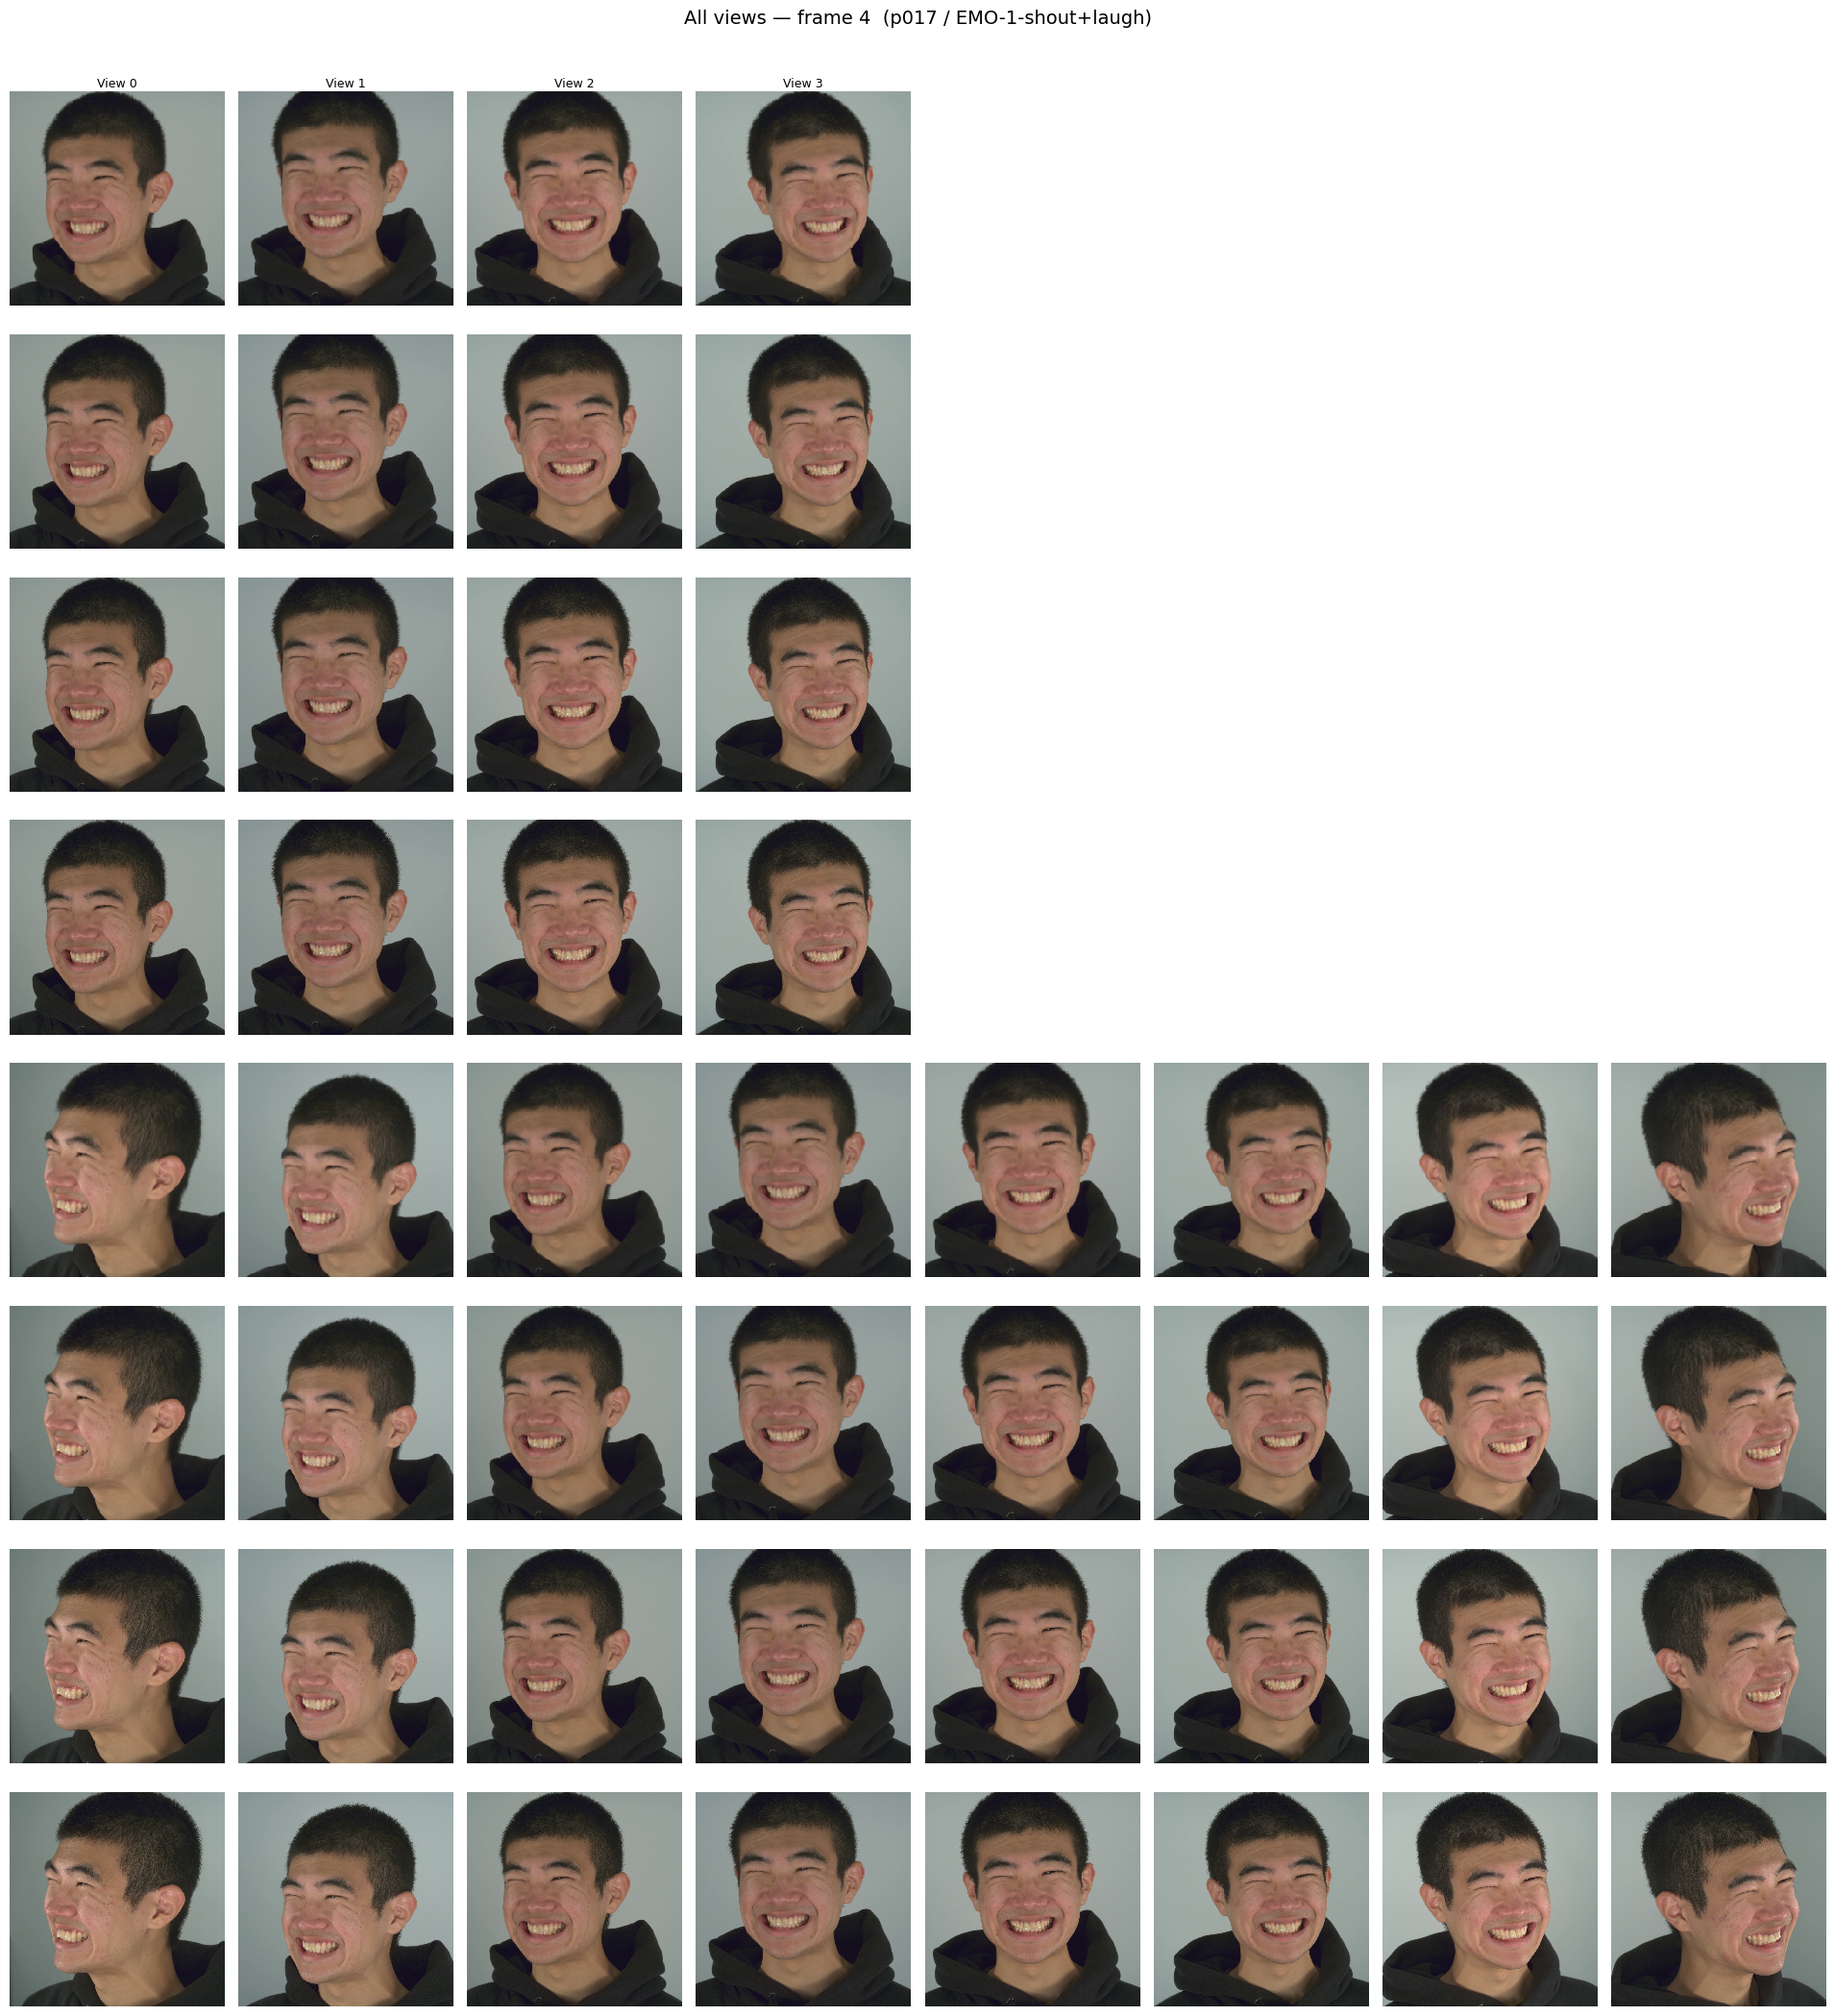

Saved to processed_data_views.png


In [4]:
# ── per-setting grid: one row per setting, one column per view ──────────────

n_settings = len(SETTINGS)
max_views  = 8  # width of the grid (fewer-view settings leave cells blank)

fig, axes = plt.subplots(
    n_settings, max_views,
    figsize=(max_views * 2.4, n_settings * 2.6),
    squeeze=False,
)
fig.suptitle(
    f'All views — frame {FRAME_IDX}  ({PERSON} / {EXPRESSION})',
    fontsize=14, y=1.01,
)

for row_idx, (root, label) in enumerate(SETTINGS):
    tensor, actual_path = load_tensor(root, PERSON, EXPRESSION)
    person_shown = os.path.basename(os.path.dirname(os.path.dirname(actual_path)))

    for col_idx in range(max_views):
        ax = axes[row_idx][col_idx]
        ax.axis('off')

        if tensor is None:
            if col_idx == 0:
                ax.text(0.5, 0.5, f'not found\n{root}',
                        ha='center', va='center', fontsize=7, color='red',
                        transform=ax.transAxes)
            continue

        V = tensor.shape[0]   # actual view count for this setting

        if col_idx < V:
            frame = tensor[col_idx, FRAME_IDX]   # (C, H, W)
            ax.imshow(to_img(frame), interpolation='nearest')
            if row_idx == 0:
                ax.set_title(f'View {col_idx}', fontsize=9, pad=3)
        # else: leave blank for settings with fewer views

        if col_idx == 0:
            ax.set_ylabel(
                f"{label}\n{tensor.shape[2]}×{tensor.shape[3]}",
                fontsize=8, rotation=0, labelpad=130, va='center',
            )

plt.tight_layout()
plt.savefig('processed_data_views.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to processed_data_views.png')

In [5]:
# ── print metadata for every setting ────────────────────────────────────────

print(f'{'Setting':<30} {'Shape (V,T,C,H,W)':<30} {'Files':<8} {'Min':>7} {'Max':>7}')
print('-' * 85)

for root, label in SETTINGS:
    tensor, actual_path = load_tensor(root, PERSON, EXPRESSION)
    n_files = len(glob.glob(os.path.join(BASE, root, '**', 'frames.pt'), recursive=True))
    if tensor is None:
        print(f'{label:<30} {'NOT FOUND':<30} {n_files:<8}')
    else:
        print(
            f'{label:<30} {str(tuple(tensor.shape)):<30}'
            f' {n_files:<8} {tensor.min().item():7.3f} {tensor.max().item():7.3f}'
        )

SyntaxError: f-string: expecting '}' (500519604.py, line 3)

In [ ]:

# ── Background removal comparison ──────────────────────────────────────────
# Old 256-res: processed WITH RVM (white background)
# New 4-frames/256-res: processed WITHOUT background removal (raw background)
# Preview from tar: what it would look like WITH alpha compositing (--use-tar-alpha)

import tarfile, tempfile as _tf, av

def read_video_frame_av(path, frame_idx=4):
    """Read a single frame from an MP4 using PyAV."""
    frames = []
    with av.open(str(path)) as c:
        for f in c.decode(video=0):
            frames.append(f.to_ndarray(format='rgb24'))
            if len(frames) > frame_idx:
                break
    return frames[frame_idx] if len(frames) > frame_idx else frames[-1]

def composite_white(rgb_hw3, alpha_hw3):
    """Composite RGB over white background using grayscale alpha (0=background, 255=foreground)."""
    alpha = alpha_hw3[:, :, 0:1].astype(np.float32) / 255.0
    rgb   = rgb_hw3.astype(np.float32) / 255.0
    if alpha.shape[:2] != rgb.shape[:2]:
        from PIL import Image as _PIL
        ah, aw = alpha.shape[:2]
        rh, rw = rgb.shape[:2]
        a_pil = _PIL.fromarray((alpha[:,:,0] * 255).astype(np.uint8), mode='L')
        a_pil = a_pil.resize((rw, rh), _PIL.BILINEAR)
        alpha = np.array(a_pil).astype(np.float32)[:,:,None] / 255.0
    comp = rgb * alpha + np.ones_like(rgb) * (1.0 - alpha)
    return (comp * 255).clip(0, 255).astype(np.uint8)

SERIAL   = '222200036'
PERSON   = 'p017'
TAR_PATH = '/datasets/lindell-proj/neumayr/nersemble_v2/017.tar'
VIS_FRAME = 4

tmp = Path(_tf.mkdtemp())
with tarfile.open(TAR_PATH) as tf:
    for m in ['017/sequences/EMO-1-shout+laugh/images/cam_222200036.mp4',
              '017/sequences/EMO-1-shout+laugh/alpha_maps/cam_222200036.mp4']:
        tf.extract(m, tmp, filter='data')

img_raw   = read_video_frame_av(tmp / '017/sequences/EMO-1-shout+laugh/images/cam_222200036.mp4', VIS_FRAME)
alpha_raw = read_video_frame_av(tmp / '017/sequences/EMO-1-shout+laugh/alpha_maps/cam_222200036.mp4', VIS_FRAME)
img_comp  = composite_white(img_raw, alpha_raw)

# load old (RVM-processed) and new (raw) tensors for same person
old_t = torch.load(f'{BASE}/256-res/{PERSON}/EMO-1-shout+laugh/frames.pt', map_location='cpu', weights_only=True)
new_t = torch.load(f'{BASE}/4-frames/256-res/{PERSON}/EMO-1-shout+laugh/frames.pt', map_location='cpu', weights_only=True)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Background removal comparison — view 0 / frame 4', fontsize=12)

panels = [
    (img_raw,                                    'Raw from tar\n(full res, no resize)'),
    (alpha_raw,                                  'Alpha map from tar\n(half-res, grayscale)'),
    (img_comp,                                   'Composited with tar alpha\n(--use-tar-alpha result)'),
    (to_img(new_t[0, FRAME_IDX]),                '4-frames/256-res (current)\nNO background removal'),
    (to_img(old_t[0, FRAME_IDX]),                '256-res (old processing)\nRVM background removal'),
]

for ax, (img, title) in zip(axes, panels):
    if isinstance(img, np.ndarray):
        ax.imshow(img, interpolation='bilinear')
    else:
        ax.imshow(img, interpolation='nearest')
    ax.set_title(title, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('bg_removal_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to bg_removal_comparison.png')


In [ ]:
# ── temporal strip for one setting (all 9 frames, one view) ─────────────────

STRIP_SETTING = '4-frames/256-res'
STRIP_VIEW    = 0

tensor, _ = load_tensor(STRIP_SETTING, PERSON, EXPRESSION)
T = tensor.shape[1]

fig, axes = plt.subplots(1, T, figsize=(T * 2.4, 2.8), squeeze=False)
fig.suptitle(
    f'Temporal strip — {STRIP_SETTING}  view {STRIP_VIEW}  ({PERSON} / {EXPRESSION})',
    fontsize=11,
)
for t in range(T):
    ax = axes[0][t]
    ax.imshow(to_img(tensor[STRIP_VIEW, t]), interpolation='nearest')
    ax.set_title(f't={t}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('temporal_strip.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to temporal_strip.png')

In [6]:
# ── compare same person across ALL resolutions (4-view, frame 4, view 0) ────

RES_SETTINGS = [
    ('4-frames/256-res',  '256 px'),
    ('4-frames/512-res',  '512 px'),
    ('4-frames/1024-res', '1024 px'),
    ('4-frames/2048-res', '2048 px'),
]

fig, axes = plt.subplots(1, len(RES_SETTINGS), figsize=(len(RES_SETTINGS) * 4, 4.5))
fig.suptitle(f'Resolution comparison — view 0 · frame {FRAME_IDX}  ({PERSON})', fontsize=12)

for ax, (root, label) in zip(axes, RES_SETTINGS):
    tensor, _ = load_tensor(root, PERSON, EXPRESSION)
    if tensor is not None:
        ax.imshow(to_img(tensor[0, FRAME_IDX]), interpolation='nearest')
    ax.set_title(label, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('resolution_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to resolution_comparison.png')

: 